In [1]:
# 导入所需库
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
print('Hello World!')
'Hello World!'

Hello World!


'Hello World!'

In [3]:
# Kernel 跨 Cell 共享变量演示: 定义函数
def square(x):
    return x * x

print('square() defined')

square() defined


In [4]:
# 在另一个 Cell 中调用
num = random.randint(1, 10)
result = square(num)
print(f'{num} squared is {result}')

3 squared is 9


In [5]:
# 选择排序算法
def selection_sort(arr):
    n = len(arr)
    sorted_arr = arr.copy()
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if sorted_arr[j] < sorted_arr[min_idx]:
                min_idx = j
        sorted_arr[i], sorted_arr[min_idx] = sorted_arr[min_idx], sorted_arr[i]
    return sorted_arr

test_list = [64, 25, 12, 22, 11]
print(f'Original: {test_list}')
print(f'Sorted:   {selection_sort(test_list)}')

Original: [64, 25, 12, 22, 11]
Sorted:   [11, 12, 22, 25, 64]


In [6]:
# 选择排序完整测试
def test_selection_sort():
    test_cases = [
        ([64, 25, 12, 22, 11], [11, 12, 22, 25, 64]),
        ([1, 2, 3, 4, 5],     [1, 2, 3, 4, 5]),
        ([5, 4, 3, 2, 1],     [1, 2, 3, 4, 5]),
        ([1],                 [1]),
        ([],                  []),
        ([3, 1, 3, 2, 1],     [1, 1, 2, 3, 3]),
    ]
    all_passed = True
    for inp, exp in test_cases:
        res = selection_sort(inp)
        if res == exp:
            print(f'[PASS] {inp} -> {res}')
        else:
            print(f'[FAIL] {inp} -> {res} (expected {exp})')
            all_passed = False
    if all_passed:
        print(f'\nAll {len(test_cases)} tests passed!')
    return all_passed

test_selection_sort()

[PASS] [64, 25, 12, 22, 11] -> [11, 12, 22, 25, 64]
[PASS] [1, 2, 3, 4, 5] -> [1, 2, 3, 4, 5]
[PASS] [5, 4, 3, 2, 1] -> [1, 2, 3, 4, 5]
[PASS] [1] -> [1]
[PASS] [] -> []
[PASS] [3, 1, 3, 2, 1] -> [1, 1, 2, 3, 3]

All 6 tests passed!


True

In [7]:
# 加载 Fortune 500 数据集
df = pd.read_csv('fortune500.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2550, 5)
Columns: ['Year', 'Rank', 'Company', 'Revenue', 'Profit']


,Year,Rank,Company,Revenue,Profit
0,1955,1,Amoco,1738.0,13411.8
1,1955,2,DuPont,29729.4,816.5
2,1955,3,General Electric,28281.6,5488.0
3,1955,4,Raytheon,29668.7,-
4,1955,5,Eastman Kodak,35057.9,18930.3


In [8]:
# 基本统计信息
df.describe()

,Year,Rank,Revenue
count,2550.000000,2550.0000,2550.000000
mean,1980.000000,25.5000,25360.984824
std,14.722488,14.4337,14373.622033
min,1955.000000,1.0000,526.900000
25%,1967.000000,13.0000,12876.050000
50%,1980.000000,25.5000,25203.550000
75%,1993.000000,38.0000,38057.400000
max,2005.000000,50.0000,49998.800000


In [9]:
# 检查各列数据类型 (Profit 应该包含非数值值)
print('Data types:')
print(df.dtypes)

Data types:
Year         int64
Rank         int64
Company     object
Revenue    float64
Profit      object
dtype: object


In [10]:
# 查找 Profit 列中的非数值记录 (N.A., -, 等)
non_num = df[df['Profit'].astype(str).str.contains('[^0-9.-]')]
print(f'Non-numeric profit records: {len(non_num)}')
non_num[['Company', 'Revenue', 'Profit']].head(10)

Non-numeric profit records: 58


,Company,Revenue,Profit
43,Mobil,8649.5,N.A.
122,Eli Lilly,22684.6,N.A.
129,Wells Fargo,9382.4,N.A.
153,Wendy's International,41333.9,N.A.
179,UnitedHealth Group,13138.7,N.A.
210,Walmart,29648.2,N.A.
285,Wm. Wrigley Jr.,30038.6,N.A.
338,Bristol-Myers Squibb,14644.5,N.A.
372,Dell,43898.8,N.A.
427,Abbott Laboratories,33134.6,N.A.


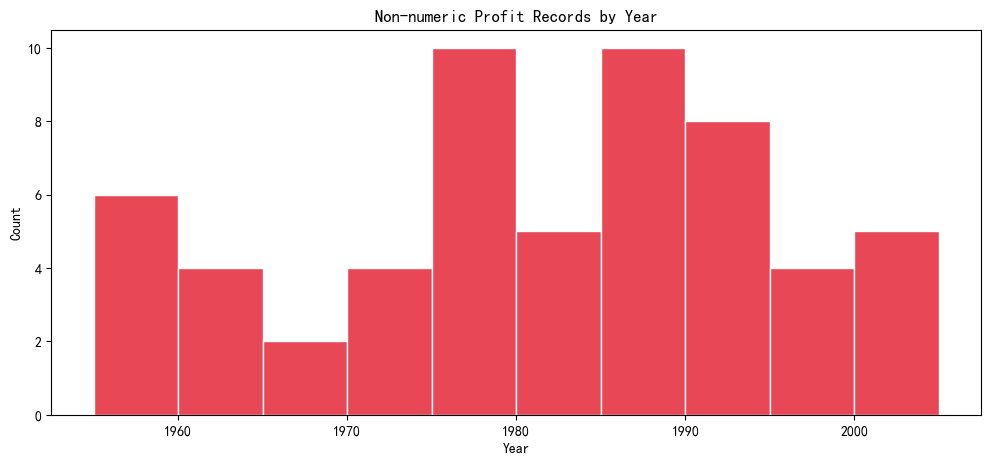

Total: 2550, Non-numeric: 58, Ratio: 2.27%


In [11]:
# 非数值记录按年份分布
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(non_num['Year'], bins=range(1955, 2006, 5), color='#E84855', edgecolor='white')
ax.set_title('Non-numeric Profit Records by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.show()

total = len(df)
bad = len(non_num)
print(f'Total: {total}, Non-numeric: {bad}, Ratio: {bad/total*100:.2f}%')

In [12]:
# 数据清洗: 使用 errors='coerce' 将非数值转为 NaN，再删除
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df = df.dropna(subset=['Profit'])

print('Data types after cleaning:')
print(df.dtypes)
print(f'\nRecords after cleaning: {len(df)}')

Data types after cleaning:
Year         int64
Rank         int64
Company     object
Revenue    float64
Profit     float64
dtype: object

Records after cleaning: 2472


In [13]:
# 按 Year 分组计算平均值
group_by_year = df.groupby('Year').agg({
    'Revenue': 'mean',
    'Profit': 'mean'
})

group_by_year.head(10)

,Revenue,Profit
Year,,
1955,26588.053191,6835.593617
1956,25340.076000,6149.692000
1957,24386.754167,5772.831250
1958,30290.829167,9033.064583
1959,23293.134694,8417.900000
1960,29307.851020,7699.177551
1961,24852.365306,7936.569388
1962,25743.391667,9706.454167
1963,22290.077083,7175.133333


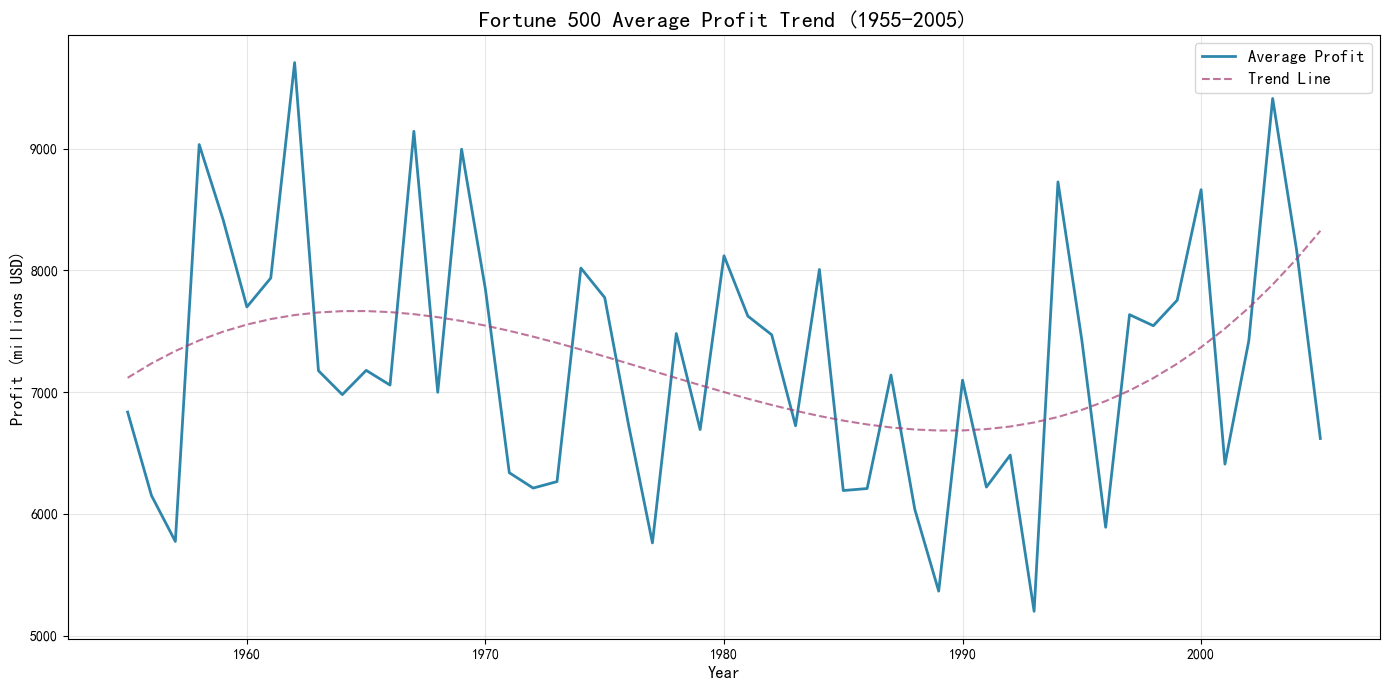

In [14]:
# 平均利润趋势图（含 3 阶多项式趋势线）
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(group_by_year.index, group_by_year['Profit'],
        color='#2E86AB', linewidth=2, label='Average Profit')

# 趋势线
z = np.polyfit(group_by_year.index, group_by_year['Profit'], 3)
p = np.poly1d(z)
ax.plot(group_by_year.index, p(group_by_year.index),
        '--', color='#A23B72', linewidth=1.5, alpha=0.7, label='Trend Line')

ax.set_title('Fortune 500 Average Profit Trend (1955-2005)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Profit (millions USD)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

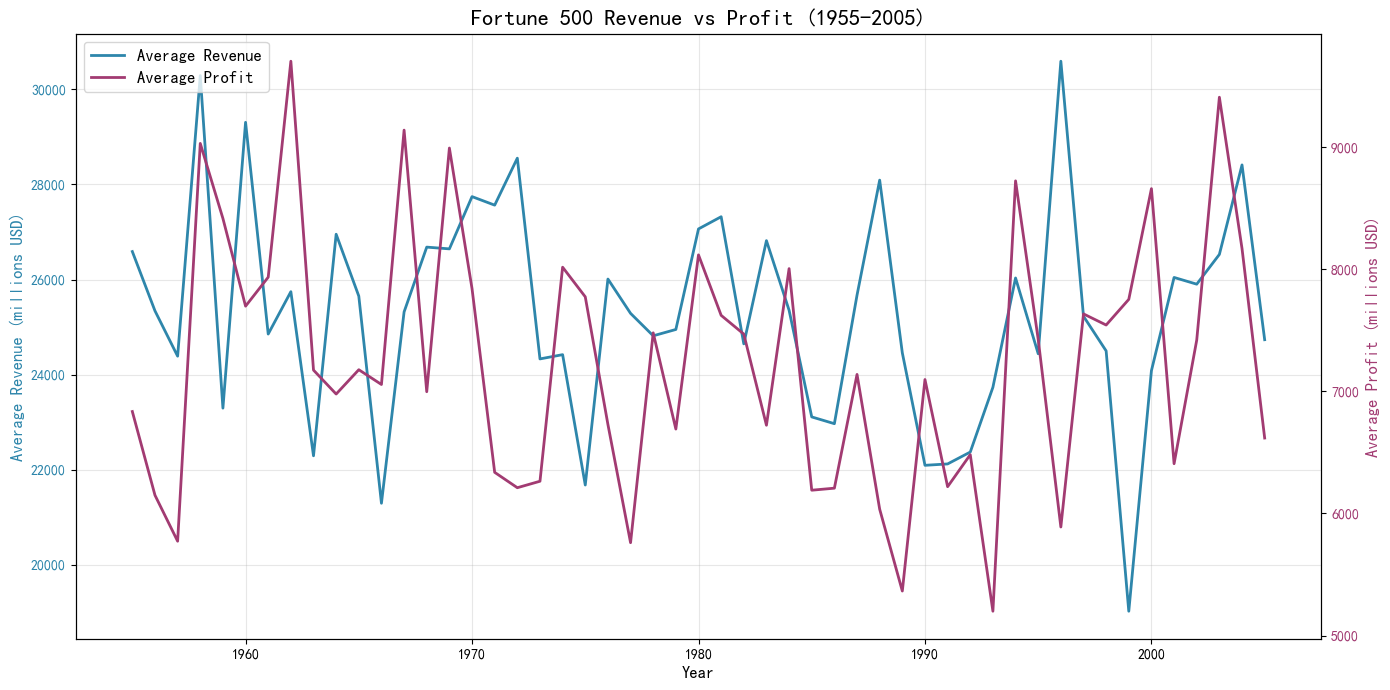

In [15]:
# 收入与利润双 Y 轴对比图
fig, ax1 = plt.subplots(figsize=(14, 7))

color1 = '#2E86AB'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Revenue (millions USD)', color=color1, fontsize=12)
line1 = ax1.plot(group_by_year.index, group_by_year['Revenue'],
                  color=color1, linewidth=2, label='Average Revenue')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Average Profit (millions USD)', color=color2, fontsize=12)
line2 = ax2.plot(group_by_year.index, group_by_year['Profit'],
                  color=color2, linewidth=2, label='Average Profit')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Fortune 500 Revenue vs Profit (1955-2005)', fontsize=16, fontweight='bold')
lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()